# Final Training and Final Test Evaluation

This is the one and only time the final test set gets touched. Every model choice up to this point (which model family, which configuration, how many boosting rounds, the ensemble method, the classification threshold) was frozen using training data only. Here, the three tuned models are trained once on the full training set and evaluated once on the untouched test set.


## Import libraries


In [3]:
from pathlib import Path
import gc
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.preprocessing import OrdinalEncoder

try:
    import xgboost as xgb
    import lightgbm as lgb
    from catboost import CatBoostClassifier
except ImportError as error:
    raise ImportError(
        "Install required packages first: pip install xgboost lightgbm catboost"
    ) from error

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
print("XGBoost:", xgb.__version__)
print("LightGBM:", lgb.__version__)
print("Libraries imported successfully.")


XGBoost: 3.2.0
LightGBM: 4.6.0
Libraries imported successfully.


## Set paths and final experiment constants


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"

xgb_config_path = project_root / "data" / "modeling" / "xgboost_tuning_results" / "best_xgboost_configuration.json"
xgb_rounds_path = project_root / "data" / "modeling" / "xgboost_tuning_results" / "xgboost_tuning_selected_rounds.csv"
lgb_config_path = project_root / "data" / "modeling" / "lightgbm_tuning_results" / "best_lightgbm_configuration.json"
lgb_rounds_path = project_root / "data" / "modeling" / "lightgbm_tuning_results" / "lightgbm_tuning_selected_rounds.csv"
cat_config_path = project_root / "data" / "modeling" / "catboost_tuning_results" / "best_native_catboost_configuration.json"
cat_rounds_path = project_root / "data" / "modeling" / "catboost_tuning_results" / "native_catboost_selected_iterations.csv"

ensemble_oof_path = project_root / "data" / "modeling" / "ensemble_results" / "ensemble_oof_predictions.pkl"
threshold_summary_path = (
    project_root
    / "data"
    / "modeling"
    / "classification_cutoff_results"
    / "classification_cutoff_summary.json"
)

selected_threshold_path = (
    project_root
    / "data"
    / "modeling"
    / "classification_cutoff_results"
    / "selected_threshold.csv"
)

threshold_comparison_path = (
    project_root
    / "data"
    / "modeling"
    / "classification_cutoff_results"
    / "threshold_comparison.csv"
)

result_folder = project_root / "data" / "modeling" / "final_test_results"
model_folder = result_folder / "trained_models"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"
for folder in [result_folder, model_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)

required_paths = [
    dataset_path, training_ids_path, test_ids_path,
    xgb_config_path, xgb_rounds_path, lgb_config_path, lgb_rounds_path,
    cat_config_path, cat_rounds_path, ensemble_oof_path,
    threshold_summary_path, selected_threshold_path,
    threshold_comparison_path,
]
for path in required_paths:
    assert path.exists(), f"Required file missing: {path}"

RANDOM_STATE = 2026
EXPECTED_TRAINING_ROWS = 246008
EXPECTED_TEST_ROWS = 61503
BOOTSTRAP_REPETITIONS = 1000
print("Final choices and required files are available.")


Final choices and required files are available.


## Load frozen configurations and determine final boosting rounds


In [7]:
def load_json(path):
    with open(path) as file:
        return json.load(file)


xgb_saved = load_json(xgb_config_path)
lgb_saved = load_json(lgb_config_path)
cat_saved = load_json(cat_config_path)
threshold_summary = load_json(threshold_summary_path)

assert xgb_saved.pop("name") == "xgb_depth5_regularized"
assert lgb_saved.pop("name") == "lgb_leaves48_regularized"
assert cat_saved.pop("name") == "native_depth7_regularized"

assert (
    threshold_summary["primary_score"]
    == "raw_equal_vote"
)

assert (
    threshold_summary["final_test_used_for_selection"]
    is False
)


selected_threshold_table = pd.read_csv(
    selected_threshold_path
)

assert len(selected_threshold_table) == 1

selected_threshold = float(
    selected_threshold_table.loc[0, "threshold"]
)

assert np.isclose(
    selected_threshold,
    threshold_summary["selected_threshold"],
)


training_threshold_comparison = pd.read_csv(
    threshold_comparison_path
)


xgb_round_table = pd.read_csv(xgb_rounds_path)
lgb_round_table = pd.read_csv(lgb_rounds_path)
cat_round_table = pd.read_csv(cat_rounds_path)


xgb_final_rounds = int(round(
    xgb_round_table.loc[
        xgb_round_table["configuration"].eq(
            "xgb_depth5_regularized"
        ),
        "selected_rounds",
    ].median()
))

lgb_final_rounds = int(round(
    lgb_round_table.loc[
        lgb_round_table["configuration"].eq(
            "lgb_leaves48_regularized"
        ),
        "selected_rounds",
    ].median()
))

cat_final_rounds = int(round(
    cat_round_table.loc[
        cat_round_table["configuration"].eq(
            "native_depth7_regularized"
        ),
        "selected_iterations",
    ].median()
))


print(
    "Final rounds:",
    xgb_final_rounds,
    lgb_final_rounds,
    cat_final_rounds,
)

print(
    "Primary ensemble score:",
    threshold_summary["primary_score"],
)

print(
    "Frozen F1 threshold:",
    round(selected_threshold, 10),
)

print(
    "Final test used for threshold selection:",
    threshold_summary[
        "final_test_used_for_selection"
    ],
)

Final rounds: 1445 1396 2647
Primary ensemble score: raw_equal_vote
Frozen F1 threshold: 0.1619911461
Final test used for threshold selection: False


Pulls in the exact settings chosen by the tuning notebooks for each model family, plus the frozen classification threshold, so nothing gets re-decided here.


## Load the training and test sets


In [10]:
full_data = pd.read_pickle(dataset_path)
training_ids = pd.read_csv(training_ids_path)["SK_ID_CURR"]
test_ids = pd.read_csv(test_ids_path)["SK_ID_CURR"]
training_id_set = set(training_ids)
test_id_set = set(test_ids)

assert training_id_set.isdisjoint(test_id_set)
training_data = full_data.loc[
    full_data["SK_ID_CURR"].isin(training_id_set)
].copy().sort_values("SK_ID_CURR").reset_index(drop=True)
test_data = full_data.loc[
    full_data["SK_ID_CURR"].isin(test_id_set)
].copy().sort_values("SK_ID_CURR").reset_index(drop=True)

assert len(training_data) == EXPECTED_TRAINING_ROWS
assert len(test_data) == EXPECTED_TEST_ROWS
assert training_data["SK_ID_CURR"].is_unique
assert test_data["SK_ID_CURR"].is_unique
print("Training rows:", len(training_data))
print("Final test rows:", len(test_data))
print("Training default rate:", round(training_data["TARGET"].mean(), 5))
print("Test target is now opened for final evaluation only.")


Training rows: 246008
Final test rows: 61503
Training default rate: 0.08073
Test target is now opened for final evaluation only.


Training and test sets loaded fresh, and confirmed to not overlap, before anything else happens.


## Prepare predictors


In [13]:
excluded_columns = ["SK_ID_CURR", "TARGET", "FOLD", "CODE_GENDER"]
predictor_columns = [c for c in training_data.columns if c not in excluded_columns]
categorical_columns = training_data[predictor_columns].select_dtypes(exclude="number").columns.tolist()
numerical_columns = [c for c in predictor_columns if c not in categorical_columns]

X_training = training_data[predictor_columns].copy()
X_test = test_data[predictor_columns].copy()
y_training = training_data["TARGET"].astype("int8").copy()
y_test = test_data["TARGET"].astype("int8").copy()

for column in categorical_columns:
    X_training[column] = X_training[column].fillna("Unknown").astype(str)
    X_test[column] = X_test[column].fillna("Unknown").astype(str)

def make_preprocessor():
    return ColumnTransformer([
        ("numeric", "passthrough", numerical_columns),
        ("categorical", OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1,
            dtype=np.float32
        ), categorical_columns),
    ], sparse_threshold=0.0)

print("Predictors:", len(predictor_columns))
print("Numerical:", len(numerical_columns))
print("Categorical:", len(categorical_columns))
print("Protected gender excluded:", "CODE_GENDER" not in predictor_columns)


Predictors: 330
Numerical: 318
Categorical: 12
Protected gender excluded: True


Same 330 predictors, same exclusion of CODE_GENDER, as every other modelling notebook.


## Build the frozen final models


In [16]:
def build_final_xgboost():
    return xgb.XGBClassifier(
        n_estimators=xgb_final_rounds,
        **xgb_saved,
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", max_bin=255, missing=np.nan,
        n_jobs=-1, random_state=RANDOM_STATE,
    )

def build_final_lightgbm():
    return lgb.LGBMClassifier(
        n_estimators=lgb_final_rounds,
        **lgb_saved,
        objective="binary", max_bin=255,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1,
    )

def build_final_catboost():
    return CatBoostClassifier(
        iterations=cat_final_rounds,
        **cat_saved,
        loss_function="Logloss", eval_metric="AUC",
        bootstrap_type="Bayesian", one_hot_max_size=10,
        random_seed=RANDOM_STATE, thread_count=-1,
        allow_writing_files=False, verbose=False,
    )

print("Frozen model builders created.")


Frozen model builders created.


Builds each model using its already-tuned settings and the median round count from cross-validation, nothing here is re-tuned.


## Train on all training rows and predict the test


In [19]:
training_log = []

# XGBoost and LightGBM use the same fold-free preprocessing fitted on all training rows.
preprocessor = make_preprocessor()
X_training_encoded = preprocessor.fit_transform(X_training).astype("float32")
X_test_encoded = preprocessor.transform(X_test).astype("float32")
joblib.dump(preprocessor, model_folder / "final_ordinal_preprocessor.joblib")

xgb_model = build_final_xgboost()
start = time.time()
xgb_model.fit(X_training_encoded, y_training, verbose=False)
xgb_probability = xgb_model.predict_proba(X_test_encoded)[:, 1]
training_log.append({"model": "xgboost", "training_minutes": (time.time() - start) / 60})
xgb_model.save_model(model_folder / "final_xgboost.json")
print("XGBoost trained and predicted.")

lgb_model = build_final_lightgbm()
start = time.time()
lgb_model.fit(X_training_encoded, y_training)
lgb_probability = lgb_model.predict_proba(X_test_encoded)[:, 1]
training_log.append({"model": "lightgbm", "training_minutes": (time.time() - start) / 60})
lgb_model.booster_.save_model(model_folder / "final_lightgbm.txt")
print("LightGBM trained and predicted.")

del X_training_encoded, X_test_encoded
gc.collect()

cat_model = build_final_catboost()
start = time.time()
cat_model.fit(
    X_training, y_training,
    cat_features=categorical_columns, verbose=False
)
cat_probability = cat_model.predict_proba(X_test)[:, 1]
training_log.append({"model": "catboost", "training_minutes": (time.time() - start) / 60})
cat_model.save_model(model_folder / "final_catboost.cbm")
print("CatBoost trained and predicted.")

training_log = pd.DataFrame(training_log)
training_log


XGBoost trained and predicted.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM trained and predicted.
CatBoost trained and predicted.


,model,training_minutes
0,xgboost,0.653604
1,lightgbm,0.822476
2,catboost,5.382605


Each model is trained once on all 246,008 training applicants, using the settings and round counts frozen from the earlier tuning notebooks, then used to predict the 61,503 test applicants. This is the only time these models are trained on the complete training set rather than a fold of it.


## Create the raw equal-vote ensemble score


In [22]:
ensemble_oof = pd.read_pickle(ensemble_oof_path)
assert len(ensemble_oof) == EXPECTED_TRAINING_ROWS
assert "equal_vote" in ensemble_oof.columns
assert not ensemble_oof["SK_ID_CURR"].isin(test_id_set).any()

raw_equal_vote = np.mean(
    np.column_stack([xgb_probability, lgb_probability, cat_probability]),
    axis=1,
)
assert np.isfinite(raw_equal_vote).all()
print("Raw equal-vote test scores created.")


Raw equal-vote test scores created.


Averages the three frozen models' test-set probabilities the same simple way the training ensemble was built, no re-tuning weights against the test set.


## Create the final test prediction file


In [25]:
test_predictions = pd.DataFrame({
    "SK_ID_CURR": test_data["SK_ID_CURR"],
    "TARGET": y_test,
    "CODE_GENDER": test_data["CODE_GENDER"],
    "xgboost": xgb_probability,
    "lightgbm": lgb_probability,
    "catboost": cat_probability,
    "raw_equal_vote": raw_equal_vote,
})
test_predictions.head()


,SK_ID_CURR,TARGET,CODE_GENDER,xgboost,lightgbm,catboost,raw_equal_vote
0,100003,0,F,0.027171,0.022235,0.017615,0.022340
1,100008,0,M,0.031777,0.025745,0.033290,0.030271
2,100027,0,F,0.011313,0.011092,0.008733,0.010379
3,100033,0,M,0.068513,0.056640,0.056995,0.060716
4,100043,0,F,0.028066,0.029224,0.031987,0.029759


One row per test applicant with each model's score and the final ensemble score, ready for scoring and the classification step.


## Calculate final test performance


In [28]:
def calculate_metrics(y_true, risk_score):
    risk_score = np.asarray(risk_score)
    return {
        "roc_auc": roc_auc_score(y_true, risk_score),
        "pr_auc": average_precision_score(y_true, risk_score),
        "mean_risk_score": risk_score.mean(),
        "observed_default_rate": np.asarray(y_true).mean(),
    }

evaluated_models = ["xgboost", "lightgbm", "catboost", "raw_equal_vote"]
metric_rows = []
for model_name in evaluated_models:
    row = calculate_metrics(test_predictions["TARGET"], test_predictions[model_name])
    row["model"] = model_name
    metric_rows.append(row)
test_metrics = pd.DataFrame(metric_rows)
test_metrics.round(6)


,roc_auc,pr_auc,mean_risk_score,observed_default_rate,model
0,0.792715,0.289317,0.080274,0.080728,xgboost
1,0.792156,0.289434,0.079495,0.080728,lightgbm
2,0.789384,0.284320,0.079185,0.080728,catboost
3,0.793333,0.290672,0.079651,0.080728,raw_equal_vote


The equal-vote ensemble comes out on top on the final test set too (ROC-AUC 0.793333), consistent with what the training out-of-fold predictions showed (0.791449). That closeness is exactly what you want to see, it means the model generalizes to applicants it never saw during training or tuning.


## Bootstrap 95% confidence intervals


In [31]:
rng = np.random.default_rng(RANDOM_STATE)
target_array = test_predictions["TARGET"].to_numpy()
score_array = test_predictions["raw_equal_vote"].to_numpy()
bootstrap_rows = []

for repetition in range(BOOTSTRAP_REPETITIONS):
    indices = rng.integers(0, len(target_array), len(target_array))
    sampled_target = target_array[indices]
    if np.unique(sampled_target).size < 2:
        continue
    sampled_score = score_array[indices]
    bootstrap_rows.append({
        "roc_auc": roc_auc_score(sampled_target, sampled_score),
        "pr_auc": average_precision_score(sampled_target, sampled_score),
    })

bootstrap_results = pd.DataFrame(bootstrap_rows)
confidence_intervals = pd.DataFrame([
    {
        "metric": metric,
        "lower_95": bootstrap_results[metric].quantile(0.025),
        "estimate": test_metrics.loc[test_metrics["model"].eq("raw_equal_vote"), metric].iloc[0],
        "upper_95": bootstrap_results[metric].quantile(0.975),
    }
    for metric in ["roc_auc", "pr_auc"]
])
confidence_intervals.round(6)


,metric,lower_95,estimate,upper_95
0,roc_auc,0.787122,0.793333,0.800031
1,pr_auc,0.278908,0.290672,0.303506


Resamples the test set 1,000 times to see how much the ROC-AUC and PR-AUC could plausibly vary just from which 61,503 applicants happened to end up in the test set. The interval is fairly narrow (0.787 to 0.800 for ROC-AUC), which is a good sign the 0.7933 result is stable and not a fluke.


## Apply the frozen F1-selected threshold

In [34]:
def evaluate_threshold(
    y_true,
    risk_score,
    threshold
):
    prediction = (
        np.asarray(risk_score) >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1]
    ).ravel()

    total = tn + fp + fn + tp

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    accuracy = (tn + tp) / total

    return {
        "threshold": float(threshold),
        "predicted_default_count": int(tp + fp),
        "predicted_default_rate": (tp + fp) / total,
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "specificity": specificity,
    }


# Apply the one threshold selected from training OOF predictions.
selected_test_result = evaluate_threshold(
    y_test,
    raw_equal_vote,
    selected_threshold,
)

final_classification_result = pd.DataFrame([
    selected_test_result
])


# Save the final binary prediction for each test applicant.
test_predictions["PREDICTED_DEFAULT"] = (
    test_predictions["raw_equal_vote"]
    >= selected_threshold
).astype("int8")


print("Final classification result")

display(
    final_classification_result.round(6)
)


# Evaluate other predetermined thresholds only for explanation.
comparison_rows = []

for threshold in training_threshold_comparison[
    "threshold"
].tolist():

    row = evaluate_threshold(
        y_test,
        raw_equal_vote,
        threshold,
    )

    row["selected_threshold"] = np.isclose(
        threshold,
        selected_threshold,
    )

    comparison_rows.append(row)


test_threshold_comparison = pd.DataFrame(
    comparison_rows
)


print("Higher-threshold sensitivity comparison")

display(
    test_threshold_comparison[[
        "threshold",
        "selected_threshold",
        "predicted_default_count",
        "true_positive",
        "false_positive",
        "precision",
        "recall",
        "f1_score",
    ]].round(6)
)

Final classification result


,threshold,predicted_default_count,predicted_default_rate,true_negative,false_positive,false_negative,true_positive,accuracy,precision,recall,f1_score,specificity
0,0.161991,7990,0.129912,50804,5734,2709,2256,0.862722,0.282353,0.454381,0.348283,0.898581


Higher-threshold sensitivity comparison


,threshold,selected_threshold,predicted_default_count,true_positive,false_positive,precision,recall,f1_score
0,0.050000,False,28626,4162,24464,0.145392,0.838268,0.247804
1,0.080000,False,18976,3567,15409,0.187974,0.718429,0.297983
2,0.100000,False,15014,3209,11805,0.213734,0.646324,0.321237
3,0.120000,False,12078,2869,9209,0.237539,0.577845,0.336678
4,0.140000,False,9886,2568,7318,0.259761,0.517221,0.345835
5,0.160000,False,8157,2282,5875,0.279760,0.459617,0.347813
6,0.161991,True,7990,2256,5734,0.282353,0.454381,0.348283
7,0.180000,False,6814,2038,4776,0.299090,0.410473,0.346040
8,0.200000,False,5734,1810,3924,0.315661,0.364552,0.338349
9,0.250000,False,3691,1329,2362,0.360065,0.267674,0.307070


The threshold chosen earlier (0.161991) is applied here unchanged, no re-optimizing against the test set. On the final test set this gives 86.27% accuracy, 28.24% precision, 45.44% recall, and an F1-score of 34.83%.


## Plot final test curves


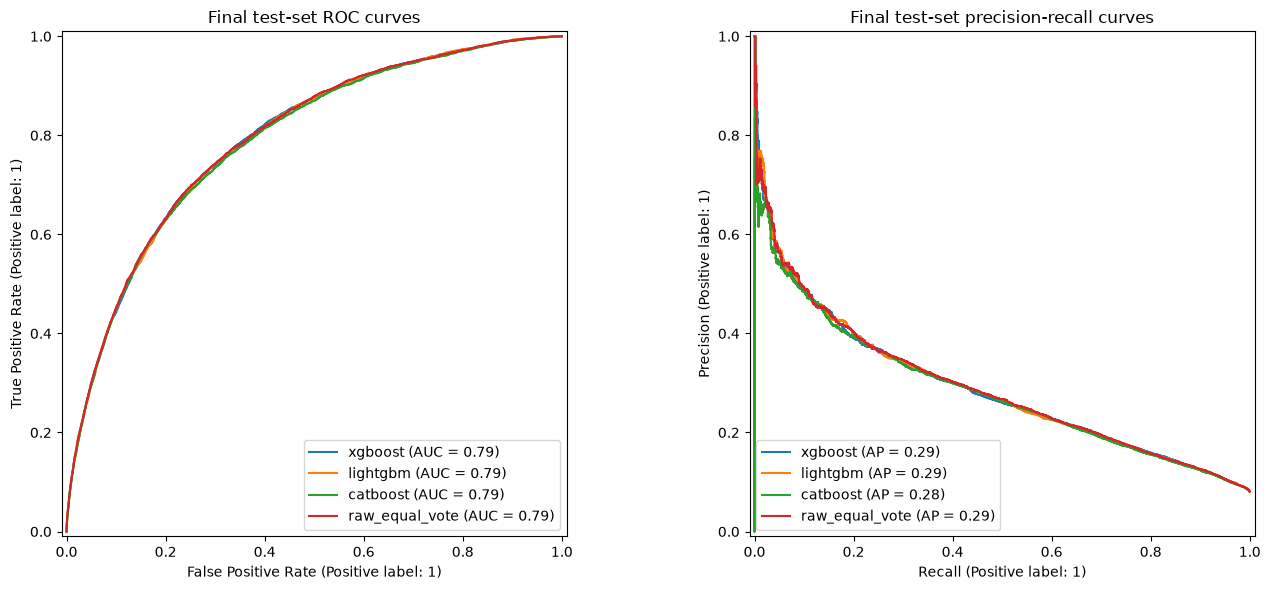

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for model_name in evaluated_models:
    RocCurveDisplay.from_predictions(
        y_test, test_predictions[model_name],
        name=model_name, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, test_predictions[model_name],
        name=model_name, ax=axes[1]
    )
axes[0].set_title("Final test-set ROC curves")
axes[1].set_title("Final test-set precision-recall curves")
plt.tight_layout()
plt.savefig(figure_folder / "final_test_curves.png", dpi=160, bbox_inches="tight")
plt.show()


Shows the ROC and precision-recall curves for all four models on the final test set, for a quick visual comparison alongside the numbers above.


## Validate and save the final results


In [40]:
frozen_choices = pd.DataFrame([
    {
        "model": "xgboost",
        "configuration": "xgb_depth5_regularized",
        "final_rounds": xgb_final_rounds,
    },
    {
        "model": "lightgbm",
        "configuration": "lgb_leaves48_regularized",
        "final_rounds": lgb_final_rounds,
    },
    {
        "model": "catboost",
        "configuration": "native_depth7_regularized",
        "final_rounds": cat_final_rounds,
    },
])

validation_checks = pd.DataFrame([
    {
        "check": "Complete training set used",
        "passed": (
            len(training_data)
            == EXPECTED_TRAINING_ROWS
        ),
    },
    {
        "check": "Complete final test set used",
        "passed": (
            len(test_data)
            == EXPECTED_TEST_ROWS
        ),
    },
    {
        "check": "Training and test sets are separate",
        "passed": (
            training_id_set.isdisjoint(test_id_set)
        ),
    },
    {
        "check": "Frozen model configurations used",
        "passed": (
            set(frozen_choices["configuration"])
            == {
                "xgb_depth5_regularized",
                "lgb_leaves48_regularized",
                "native_depth7_regularized",
            }
        ),
    },
    {
        "check": "Median training rounds used",
        "passed": (
            frozen_choices["final_rounds"]
            .gt(0)
            .all()
        ),
    },
    {
        "check": "Protected gender excluded",
        "passed": (
            "CODE_GENDER"
            not in predictor_columns
        ),
    },
    {
        "check": "All test predictions complete",
        "passed": (
            not test_predictions[
                evaluated_models
            ].isna().any().any()
        ),
    },
    {
        "check": "One prediction per test applicant",
        "passed": (
            len(test_predictions)
            == EXPECTED_TEST_ROWS
            and test_predictions[
                "SK_ID_CURR"
            ].is_unique
        ),
    },
    {
        "check": "Raw equal voting used",
        "passed": np.allclose(
            raw_equal_vote,
            np.mean(
                np.column_stack([
                    xgb_probability,
                    lgb_probability,
                    cat_probability,
                ]),
                axis=1,
            ),
        ),
    },
    {
        "check": "Frozen F1 threshold used",
        "passed": np.isclose(
            final_classification_result.loc[
                0,
                "threshold",
            ],
            selected_threshold,
        ),
    },
    {
        "check": "Test excluded from threshold selection",
        "passed": (
            threshold_summary[
                "final_test_used_for_selection"
            ]
            is False
        ),
    },
    {
        "check": "Binary predictions complete",
        "passed": (
            test_predictions[
                "PREDICTED_DEFAULT"
            ].isin([0, 1]).all()
        ),
    },
    {
        "check": "Sensitivity thresholds evaluated",
        "passed": (
            len(test_threshold_comparison)
            == len(training_threshold_comparison)
        ),
    },
    {
        "check": "Bootstrap repetitions complete",
        "passed": (
            len(bootstrap_results)
            == BOOTSTRAP_REPETITIONS
        ),
    },
    {
        "check": "Final metrics finite",
        "passed": np.isfinite(
            test_metrics.select_dtypes(
                include="number"
            ).to_numpy()
        ).all(),
    },
    {
        "check": "Classification metrics finite",
        "passed": np.isfinite(
            final_classification_result
            .select_dtypes(include="number")
            .to_numpy()
        ).all(),
    },
])


display(validation_checks)

assert validation_checks["passed"].all(), (
    "At least one final test validation check failed."
)


test_predictions.to_pickle(
    result_folder
    / "final_test_predictions.pkl"
)

test_predictions.to_csv(
    result_folder
    / "final_test_predictions.csv",
    index=False,
)

test_metrics.to_csv(
    result_folder
    / "final_test_metrics.csv",
    index=False,
)

bootstrap_results.to_csv(
    result_folder
    / "final_test_bootstrap_metrics.csv",
    index=False,
)

confidence_intervals.to_csv(
    result_folder
    / "final_test_confidence_intervals.csv",
    index=False,
)

final_classification_result.to_csv(
    result_folder
    / "final_test_classification_results.csv",
    index=False,
)

test_threshold_comparison.to_csv(
    result_folder
    / "final_test_threshold_comparison.csv",
    index=False,
)

training_log.to_csv(
    result_folder
    / "final_training_log.csv",
    index=False,
)

frozen_choices.to_csv(
    result_folder
    / "final_frozen_choices.csv",
    index=False,
)

pd.DataFrame({
    "predictor": predictor_columns
}).to_csv(
    result_folder
    / "final_predictor_list.csv",
    index=False,
)

validation_checks.to_csv(
    audit_folder
    / "final_test_validation.csv",
    index=False,
)


final_summary = {
    "primary_model": "raw_equal_vote",
    "final_test_roc_auc": float(
        test_metrics.loc[
            test_metrics["model"].eq(
                "raw_equal_vote"
            ),
            "roc_auc",
        ].iloc[0]
    ),
    "final_test_pr_auc": float(
        test_metrics.loc[
            test_metrics["model"].eq(
                "raw_equal_vote"
            ),
            "pr_auc",
        ].iloc[0]
    ),
    "selected_threshold": (
        selected_threshold
    ),
    "threshold_selected_using": (
        "Maximum training OOF F1-score"
    ),
    "final_test_not_used_for_model_or_threshold_selection": True,
    "test_accuracy": (
        selected_test_result["accuracy"]
    ),
    "test_precision": (
        selected_test_result["precision"]
    ),
    "test_recall": (
        selected_test_result["recall"]
    ),
    "test_f1_score": (
        selected_test_result["f1_score"]
    ),
    "test_specificity": (
        selected_test_result["specificity"]
    ),
}


with open(
    result_folder
    / "final_test_summary.json",
    "w"
) as file:
    json.dump(
        final_summary,
        file,
        indent=2,
    )


print(
    "Final test results saved in:",
    result_folder,
)

print(
    "Primary final model: "
    "raw equal-vote ensemble"
)

print(
    "Frozen F1 threshold:",
    round(selected_threshold, 10),
)

print(
    "The final test set was not used "
    "for model or threshold selection."
)

,check,passed
0,Complete training set used,True
1,Complete final test set used,True
2,Training and test sets are separate,True
3,Frozen model configurations used,True
4,Median training rounds used,True
5,Protected gender excluded,True
6,All test predictions complete,True
7,One prediction per test applicant,True
8,Raw equal voting used,True
9,Frozen F1 threshold used,True


Final test results saved in: /Users/taranveersingh/A-MRP/data/modeling/final_test_results
Primary final model: raw equal-vote ensemble
Frozen F1 threshold: 0.1619911461
The final test set was not used for model or threshold selection.


All checks passed. The final test set was used exactly once, for evaluation only, never for any decision.
